In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 2.4 s (started: 2026-06-25 23:25:52 +02:00)


In [2]:
scarf.fetch_dataset("tenx_8K_pbmc_citeseq", save_path="scarf_datasets")

time: 19.8 s (started: 2026-06-25 23:25:54 +02:00)


In [3]:
reader = scarf.CrH5Reader("scarf_datasets/tenx_8K_pbmc_citeseq/data.h5")

time: 53.9 ms (started: 2026-06-25 23:26:14 +02:00)


In [4]:
reader.assayFeats

,RNA,ADT
type,Gene Expression,Antibody Capture
start,0,33538
end,33538,33555
nFeatures,33538,17


time: 12.9 ms (started: 2026-06-25 23:26:14 +02:00)


In [5]:
reader.rename_assays({"assay2": "ADT"})
reader.assayFeats

,RNA,ADT
type,Gene Expression,Antibody Capture
start,0,33538
end,33538,33555
nFeatures,33538,17


time: 15.9 ms (started: 2026-06-25 23:26:14 +02:00)


In [6]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr",
    chunk_size=(2000, 1000),
)
writer.dump(batch_size=1000)

/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=18, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=15, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. 

/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=6, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=23, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. A

  0%|                                                                                                         …

time: 18.4 s (started: 2026-06-25 23:26:14 +02:00)


In [7]:
ds = scarf.DataStore(
    "scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr", default_assay="RNA", nthreads=4
)

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(ADT) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

(ADT) Computing nCounts:   0%|                                                                                …

(ADT) Computing nFeatures:   0%|                                                                              …

time: 12.2 s (started: 2026-06-25 23:26:33 +02:00)


In [8]:
ds

DataStore has 7865 (7865) cells with 2 assays: ADT RNA
   Cell metadata:
            'I', 'ids', 'names', 'ADT_nCounts', 'RNA_percentMito', 
            'RNA_nCounts', 'ADT_nFeatures', 'RNA_nFeatures', 'RNA_percentRibo'
   RNA assay has 13832 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          
   ADT assay has 17 (17) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 114 ms (started: 2026-06-25 23:26:45 +02:00)


In [9]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts
0,False,ENSG00000243485,MIR1302-2HG,0,7865
1,False,ENSG00000237613,FAM138A,0,7865
2,False,ENSG00000186092,OR4F5,0,7865
3,False,ENSG00000238009,AL627309.1,12,7853
4,False,ENSG00000239945,AL627309.3,0,7865


time: 69.5 ms (started: 2026-06-25 23:26:45 +02:00)


In [10]:
ds.ADT.feats.head()

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1


time: 67.3 ms (started: 2026-06-25 23:26:45 +02:00)


INFO: 154 cells flagged for filtering out using attribute RNA_nCounts


INFO: 326 cells flagged for filtering out using attribute RNA_nFeatures


INFO: 119 cells flagged for filtering out using attribute RNA_percentMito


INFO: 21 cells flagged for filtering out using attribute RNA_percentRibo


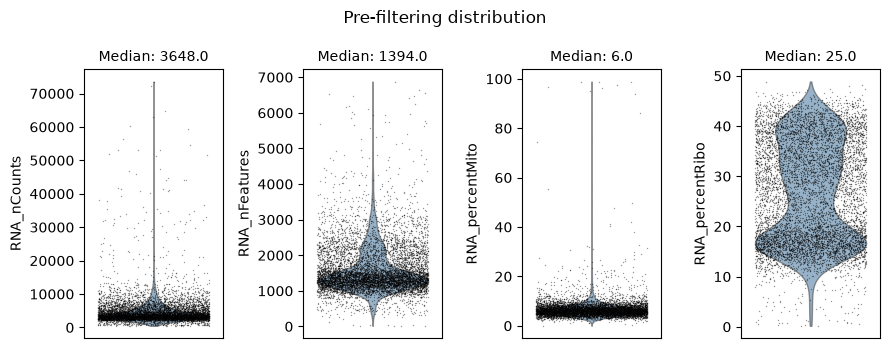

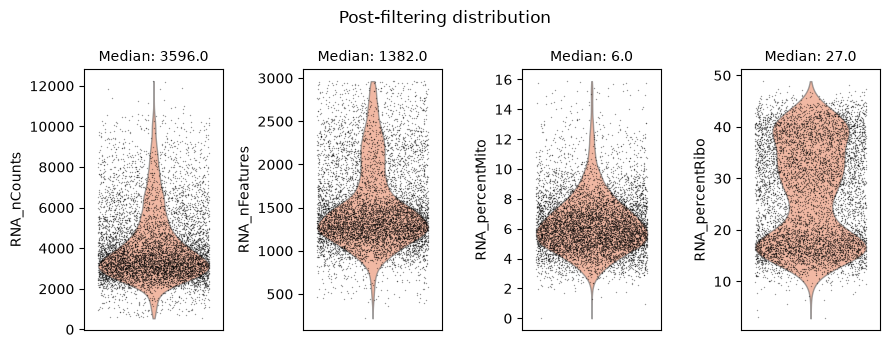

time: 4.38 s (started: 2026-06-25 23:26:45 +02:00)


In [11]:
ds.auto_filter_cells()

INFO: Calculating summary statistics


(RNA) Computing nCells:   0%|                                                                                 …

(RNA) Computing normed_tot:   0%|                                                                             …

(RNA) Computing sigmas:   0%|                                                                                 …

INFO: Calculating HVGs


INFO: 997 genes marked as HVGs


/home/parashar/scarf/scarf/plots.py:392: RuntimeWarning: divide by zero encountered in log2
  nzm = np.log2(nzm)
/home/parashar/scarf/scarf/plots.py:393: RuntimeWarning: divide by zero encountered in log2
  fv = np.log2(fv)


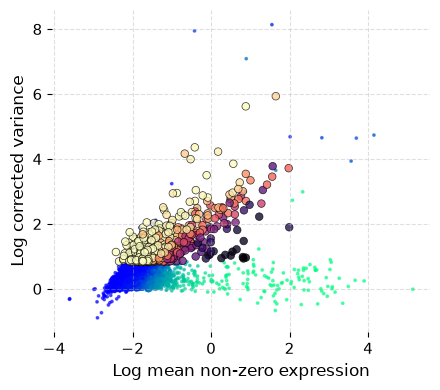

Writing data to normed__I__hvgs/data:   0%|                                                                   …

Calculating mean of norm. data:   0%|                                                                         …

Calculating std. dev. of norm. data:   0%|                                                                    …

Fitting PCA:   0%|                                                                                            …

Fitting ANN:   0%|                                                                                            …

...

	completed  150  /  250 epochs


	completed  175  /  250 epochs


	completed  200  /  250 epochs


	completed  225  /  250 epochs


time: 1min 29s (started: 2026-06-25 23:26:50 +02:00)


In [12]:
ds.mark_hvgs(min_cells=20, top_n=1000, min_mean=-3, max_mean=2, max_var=6)

ds.make_graph(feat_key="hvgs", k=21, dims=15, n_centroids=100)

ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)

ds.run_leiden_clustering(resolution=1)

/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


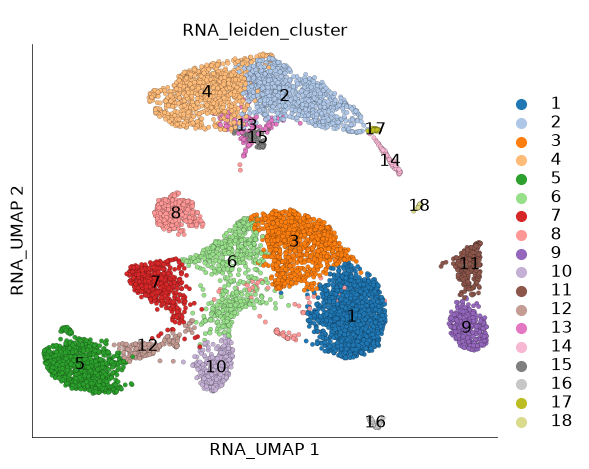

time: 854 ms (started: 2026-06-25 23:28:19 +02:00)


In [13]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="RNA_leiden_cluster", cmap="tab20")

In [14]:
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,dropOuts,nCells
0,True,CD3,CD3_TotalSeqB,1,7864
1,True,CD4,CD4_TotalSeqB,1,7864
2,True,CD8a,CD8a_TotalSeqB,2,7863
3,True,CD14,CD14_TotalSeqB,1,7864
4,True,CD15,CD15_TotalSeqB,1,7864
5,True,CD16,CD16_TotalSeqB,1,7864
6,True,CD56,CD56_TotalSeqB,1,7864
7,True,CD19,CD19_TotalSeqB,163,7702
8,True,CD25,CD25_TotalSeqB,4,7861
9,True,CD45RA,CD45RA_TotalSeqB,1,7864


time: 90.2 ms (started: 2026-06-25 23:28:20 +02:00)


In [15]:
adt_names = ds.ADT.feats.to_pandas_dataframe(["names"])["names"]
adt_names

0               CD3_TotalSeqB
1               CD4_TotalSeqB
2              CD8a_TotalSeqB
3              CD14_TotalSeqB
4              CD15_TotalSeqB
5              CD16_TotalSeqB
6              CD56_TotalSeqB
7              CD19_TotalSeqB
8              CD25_TotalSeqB
9            CD45RA_TotalSeqB
10           CD45RO_TotalSeqB
11             PD-1_TotalSeqB
12            TIGIT_TotalSeqB
13            CD127_TotalSeqB
14    IgG2a_control_TotalSeqB
15     IgG1_control_TotalSeqB
16    IgG2b_control_TotalSeqB
Name: names, dtype: object

time: 27.8 ms (started: 2026-06-25 23:28:20 +02:00)


In [16]:
is_control = adt_names.str.contains("control").values
is_control

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True])

time: 2.87 ms (started: 2026-06-25 23:28:20 +02:00)


In [17]:
ds.ADT.feats.update_key(~is_control, "I")
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,dropOuts,nCells
0,True,CD3,CD3_TotalSeqB,1,7864
1,True,CD4,CD4_TotalSeqB,1,7864
2,True,CD8a,CD8a_TotalSeqB,2,7863
3,True,CD14,CD14_TotalSeqB,1,7864
4,True,CD15,CD15_TotalSeqB,1,7864
5,True,CD16,CD16_TotalSeqB,1,7864
6,True,CD56,CD56_TotalSeqB,1,7864
7,True,CD19,CD19_TotalSeqB,163,7702
8,True,CD25,CD25_TotalSeqB,4,7861
9,True,CD45RA,CD45RA_TotalSeqB,1,7864


time: 123 ms (started: 2026-06-25 23:28:20 +02:00)


In [18]:
print(ds.ADT)
print(ds.ADT.normMethod.__name__)

ADTassay ADT with 14(17) features
norm_clr
time: 16.4 ms (started: 2026-06-25 23:28:20 +02:00)


In [19]:
ds.make_graph(from_assay="ADT", feat_key="I", k=21, dims=0, n_centroids=100)

Writing data to normed__I__I/data:   0%|                                                                      …

Calculating mean of norm. data:   0%|                                                                         …

Calculating std. dev. of norm. data:   0%|                                                                    …

Fitting ANN:   0%|                                                                                            …

Fitting kmeans:   0%|                                                                                         …

Estimating seed partitions:   0%|                                                                             …

Identifying neighbors:   0%|                                                                                  …

Smoothening KNN distances:   0%|                                                                              …

INFO: ANN recall: 99.99%


time: 1.62 s (started: 2026-06-25 23:28:20 +02:00)


In [20]:
ds.run_umap(from_assay="ADT", n_epochs=250, spread=5, min_dist=1, parallel=True)

ds.run_leiden_clustering(from_assay="ADT", resolution=1)

Training UMAP:   0%|                                                                                          …

	completed  0  /  250 epochs


	completed  25  /  250 epochs


	completed  50  /  250 epochs


	completed  75  /  250 epochs


...

	completed  150  /  250 epochs


	completed  175  /  250 epochs


	completed  200  /  250 epochs


	completed  225  /  250 epochs


time: 5.44 s (started: 2026-06-25 23:28:22 +02:00)


In [21]:
ds.cells.head()

,I,ids,names,ADT_nCounts,RNA_percentMito,ADT_UMAP2,RNA_nFeatures,RNA_percentRibo,RNA_nCounts,RNA_UMAP1,ADT_UMAP1,RNA_leiden_cluster,ADT_nFeatures,ADT_leiden_cluster,RNA_UMAP2
0,True,AAACCCAAGATTGTGA-1,AAACCCAAGATTGTGA-1,981.0,8.668831,-10.324353,2194.0,15.259740,6160.0,-14.576731,-32.984264,4,17.0,5,30.462261
1,True,AAACCCACATCGGTTA-1,AAACCCACATCGGTTA-1,1475.0,6.316103,-22.145508,2093.0,19.037688,6713.0,-13.891109,-21.070971,4,17.0,13,27.816746
2,True,AAACCCAGTACCGCGT-1,AAACCCAGTACCGCGT-1,7149.0,8.056090,-4.313348,1518.0,16.002200,3637.0,-1.625294,-26.066526,2,17.0,5,25.287258
3,True,AAACCCAGTATCGAAA-1,AAACCCAGTATCGAAA-1,6831.0,9.003215,-14.893117,737.0,18.729904,1244.0,-29.555759,22.877502,5,17.0,3,-23.920933
4,True,AAACCCAGTCGTCATA-1,AAACCCAGTCGTCATA-1,6839.0,6.204519,-14.185415,1240.0,16.353887,2611.0,-31.901066,24.512714,5,17.0,3,-17.240076


time: 308 ms (started: 2026-06-25 23:28:27 +02:00)


/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


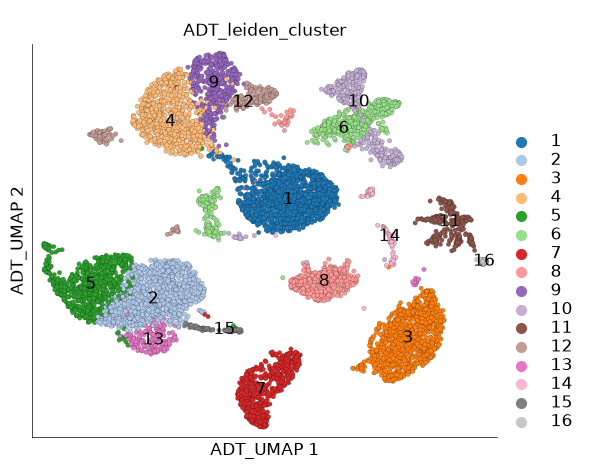

time: 594 ms (started: 2026-06-25 23:28:28 +02:00)


In [22]:
ds.plot_layout(layout_key="ADT_UMAP", color_by="ADT_leiden_cluster", cmap="tab20")

/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T
/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T
/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T
/home/parashar/scar

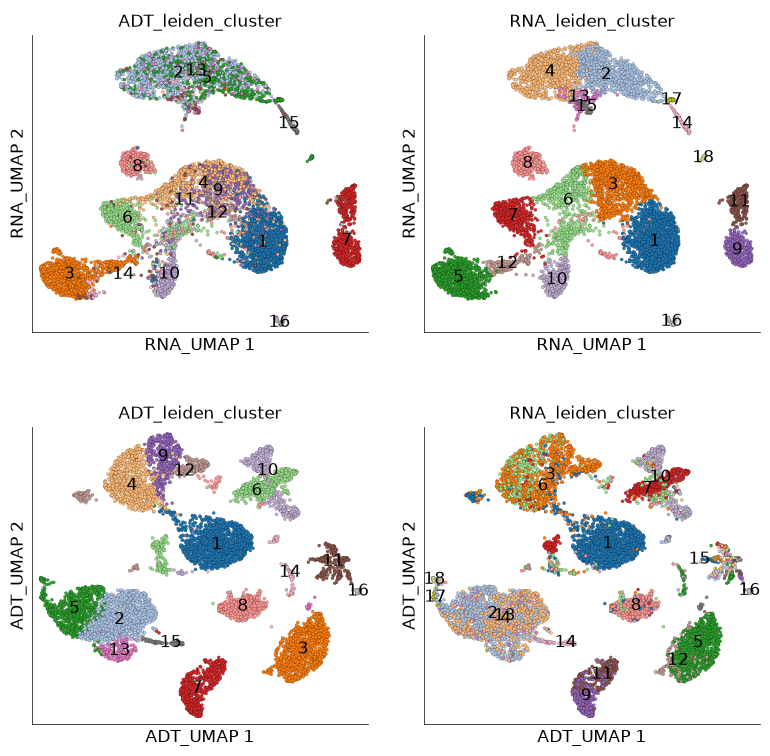

time: 1.65 s (started: 2026-06-25 23:28:28 +02:00)


In [23]:
# UMAP on RNA and coloured with clusters calculated on ADT
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by=["ADT_leiden_cluster", "RNA_leiden_cluster"],
    cmap="tab20",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
    legend_onside=False,
)

In [24]:
import pandas as pd

df = pd.crosstab(
    ds.cells.fetch("RNA_leiden_cluster"), ds.cells.fetch("ADT_leiden_cluster")
)
df

col_0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
row_0,,,,,,,,,,,,,,,,
1,1036,0,0,36,3,16,0,31,28,2,17,54,0,0,0,0
2,0,360,1,0,384,3,1,0,3,0,26,1,81,17,5,0
3,33,0,0,367,1,11,1,8,262,15,22,157,0,0,0,0
4,0,566,0,2,175,2,1,0,2,2,33,1,60,7,0,0
5,0,0,732,0,0,0,0,0,1,1,32,0,0,36,1,0
6,4,0,0,277,0,97,0,49,66,64,24,7,0,2,0,0
7,0,0,1,26,0,406,0,6,2,4,14,0,0,2,0,0
8,6,3,0,0,4,24,0,345,1,6,4,4,1,0,0,0
9,0,0,0,0,0,0,315,0,0,0,8,0,0,0,0,0


time: 132 ms (started: 2026-06-25 23:28:30 +02:00)


In [25]:
(100 * df.max() / df.sum()).sort_values(ascending=False)

col_0
16    96.666667
1     94.698355
15    86.956522
3     83.466363
8     77.008929
6     70.000000
10    69.552239
9     69.129288
12    67.672414
5     60.282575
7     60.229446
2     56.998993
4     51.617440
13    50.625000
14    45.569620
11    13.095238
dtype: float64

time: 4.7 ms (started: 2026-06-25 23:28:30 +02:00)


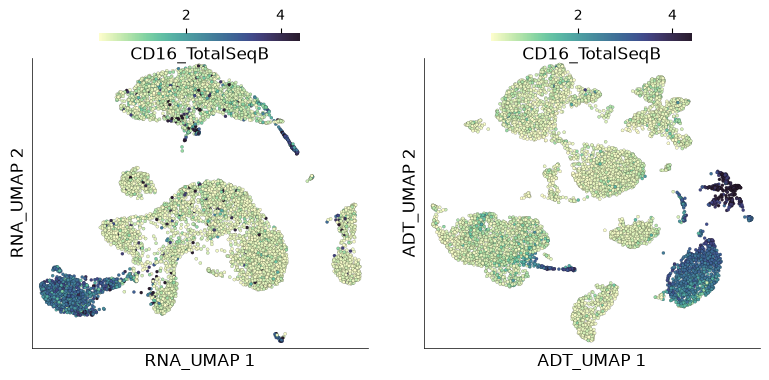

time: 1.13 s (started: 2026-06-25 23:28:30 +02:00)


In [26]:
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by="CD16_TotalSeqB",
    from_assay="ADT",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
)

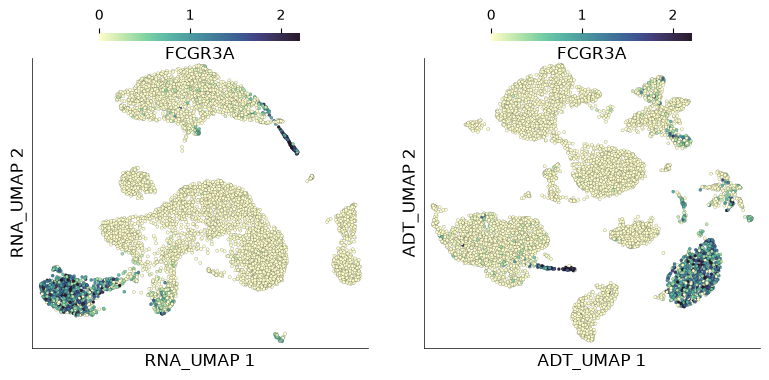

time: 1.44 s (started: 2026-06-25 23:28:31 +02:00)


In [27]:
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by="FCGR3A",
    from_assay="RNA",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
)

In [28]:
ds.integrate_assays(assays=["RNA", "ADT"], label="RNA+ADT")

Identifying SNNs in graphs:   0%|                                                                             …

Merging graph edges:   0%|                                                                                    …

time: 4.09 s (started: 2026-06-25 23:28:33 +02:00)


In [29]:
ds.run_umap(
    integrated_graph="RNA+ADT", n_epochs=500, spread=5, min_dist=0.5, parallel=True
)

ds.run_leiden_clustering(integrated_graph="RNA+ADT", resolution=1.75)

Training UMAP:   0%|                                                                                          …

	completed  0  /  500 epochs


	completed  50  /  500 epochs


	completed  100  /  500 epochs


	completed  150  /  500 epochs


...

	completed  300  /  500 epochs


	completed  350  /  500 epochs


	completed  400  /  500 epochs


	completed  450  /  500 epochs


time: 10.7 s (started: 2026-06-25 23:28:37 +02:00)


/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T
/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T
/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


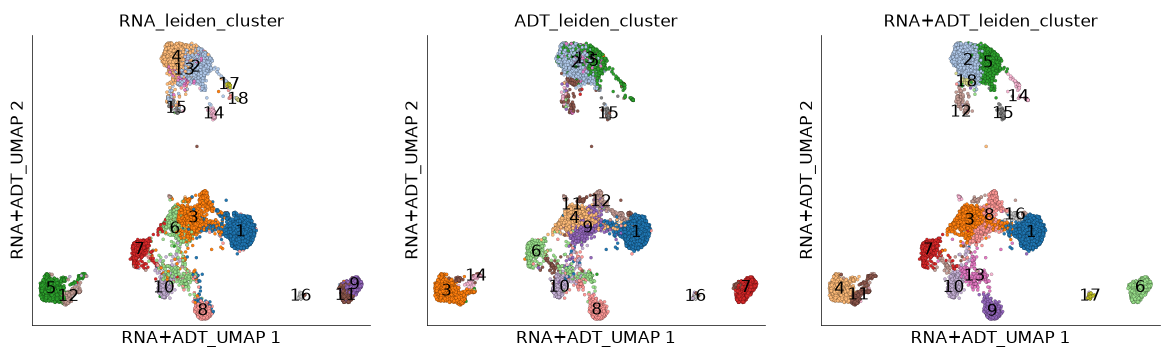

time: 696 ms (started: 2026-06-25 23:28:48 +02:00)


In [30]:
ds.plot_layout(
    layout_key=["RNA+ADT_UMAP"],
    color_by=["RNA_leiden_cluster", "ADT_leiden_cluster", "RNA+ADT_leiden_cluster"],
    cmap="tab20",
    legend_onside=False,
    point_size=5,
    width=4,
    height=4,
    n_columns=3,
)

In [31]:
ds.cells.columns

['I',
 'ids',
 'names',
 'RNA_percentMito',
 'RNA+ADT_UMAP1',
 'ADT_UMAP1',
 'ADT_nFeatures',
 'ADT_nCounts',
 'RNA+ADT_leiden_cluster',
 'ADT_UMAP2',
 'RNA_percentRibo',
 'RNA+ADT_UMAP2',
 'RNA_UMAP1',
 'RNA_nCounts',
 'RNA_nFeatures',
 'RNA_leiden_cluster',
 'ADT_leiden_cluster',
 'RNA_UMAP2']

time: 14.7 ms (started: 2026-06-25 23:28:48 +02:00)
